### **PySpark NLP: From Sentiment Analysis to Machine Learning Pipeline**

In [1]:
!pip install pyspark

In [2]:
from pyspark.sql import SparkSession


spark = SparkSession.builder.appName("analise_nlp").getOrCreate()

df = spark.read.csv(
    "imdb-reviews-pt-br.csv",
    header=True,
    inferSchema=True
)

df.show()

+---+--------------------+--------------------+--------------------+
| id|             text_en|             text_pt|           sentiment|
+---+--------------------+--------------------+--------------------+
|  1|Once again Mr. Co...|Mais uma vez, o S...|                 neg|
|  2|This is an exampl...|Este é um exemplo...|                 neg|
|  3|First of all I ha...|"Primeiro de tudo...| exceto Paxton e ...|
|  4|Not even the Beat...|Nem mesmo os Beat...|                 neg|
|  5|Brass pictures mo...|Filmes de fotos d...|                 neg|
|  6|"A funny thing ha...| the hero is a de...|           excuse me|
|  7|This German horro...|Este filme de ter...|                 neg|
|  8|"Being a long-tim...| plots and twists...|         forcedly so|
|  9|"""Tokyo Eyes"" t...|                talk| and more talk. Y...|
| 10|Wealthy horse ran...|Fazendeiros ricos...|                 neg|
| 11|"Cage plays a dru...|"Cage interpreta ...|                 neg|
| 12|First of all, I w...|Primeiro

**Explorando Dados**

Agora que já lemos os dados, vamos exlora-los entendendo:



*   o **tamanho** dos dados
*   os **campos** e o tipo
*   o **conteúdo** em cada campo
*   a **proporção** das categorias


In [3]:
# O tamanho dos dados
# count = qntd de linhas
# len(df.columns) = colunas
print(f'n° de linhas: {df.count()}')
print(f'n° de colunas: {len(df.columns)}')

n° de linhas: 30581
n° de colunas: 4


In [4]:
# campos e tipos
df.printSchema()

root
 |-- id: integer (nullable = true)
 |-- text_en: string (nullable = true)
 |-- text_pt: string (nullable = true)
 |-- sentiment: string (nullable = true)



In [5]:
# conteúdo
df.limit(190).show()

+---+--------------------+--------------------+--------------------+
| id|             text_en|             text_pt|           sentiment|
+---+--------------------+--------------------+--------------------+
|  1|Once again Mr. Co...|Mais uma vez, o S...|                 neg|
|  2|This is an exampl...|Este é um exemplo...|                 neg|
|  3|First of all I ha...|"Primeiro de tudo...| exceto Paxton e ...|
|  4|Not even the Beat...|Nem mesmo os Beat...|                 neg|
|  5|Brass pictures mo...|Filmes de fotos d...|                 neg|
|  6|"A funny thing ha...| the hero is a de...|           excuse me|
|  7|This German horro...|Este filme de ter...|                 neg|
|  8|"Being a long-tim...| plots and twists...|         forcedly so|
|  9|"""Tokyo Eyes"" t...|                talk| and more talk. Y...|
| 10|Wealthy horse ran...|Fazendeiros ricos...|                 neg|
| 11|"Cage plays a dru...|"Cage interpreta ...|                 neg|
| 12|First of all, I w...|Primeiro

In [6]:
# mostrando alguns comentários ditos como negativo ou positivo
df.filter(df.id == 190).select("text_pt").show(truncate=False)

+---------------------------------------------------------------------------+
|text_pt                                                                    |
+---------------------------------------------------------------------------+
| to a film that tries to spread an Archchristian ""Judgement day is at hand|
+---------------------------------------------------------------------------+



In [7]:
df.take(191)[189]

Row(id=190, text_en='"This is without doubt the worst movie i have ever seen. And believe me, I have seen a lot of movies. The unbelievable twist the movie makes - going from an extremely bad ""Alien lifeforms inhabit earth"" movie with sickening bad acting', text_pt=' to a film that tries to spread an Archchristian ""Judgement day is at hand', sentiment=' seek Jesus or though shall burn for all eternity in the fiery debts of hell"" message - left me stunned after being tormented for 85 minutes. Even religious Christians must be ashamed or furious by watching their beliefs being posted like this. I didnt know what to do with myself when I watched the horrible acting that could have been performed by 7-year-olds. Simply disgusting. I am not a Christian nor very religious. But if I had been')

In [8]:
df = spark.read.csv(
    "imdb-reviews-pt-br.csv",
    header=True,
    inferSchema=True,
    multiLine=True,
    escape='"'
)

In [9]:
df.take(191)[189]

Row(id=190, text_en='This is without doubt the worst movie i have ever seen. And believe me, I have seen a lot of movies. The unbelievable twist the movie makes - going from an extremely bad "Alien lifeforms inhabit earth" movie with sickening bad acting, to a film that tries to spread an Archchristian "Judgement day is at hand, seek Jesus or though shall burn for all eternity in the fiery debts of hell" message - left me stunned after being tormented for 85 minutes. Even religious Christians must be ashamed or furious by watching their beliefs being posted like this. I didnt know what to do with myself when I watched the horrible acting that could have been performed by 7-year-olds. Simply disgusting. I am not a Christian nor very religious. But if I had been, I would no longer be afraid of Hell. Rich Christiano has shown be something much, much worse.', text_pt='Este é sem dúvida o pior filme que eu já vi. E acredite em mim, eu vi muitos filmes. A reviravolta inacreditável que o film

In [10]:
# mostrando alguns comentários ditos como negativo ou positivo
df.filter(df.id == 190).select("text_pt").show(truncate=False)

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|text_pt                                                                                                                          

In [11]:
# mostrando alguns comentários ditos como negativo ou positivo
print('Negativo')
df.filter(df.id == 190).select("text_pt").show(truncate=False)
print('Positivo')
df.filter(df.id == 12427).select("text_pt").show(truncate=False)

Negativo
+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|text_pt                                                                                                                 

In [12]:
# Contabilizar os tipos de dados
df.groupBy('sentiment').count().show()

+---------+-----+
|sentiment|count|
+---------+-----+
|      pos|24694|
|      neg|24765|
+---------+-----+



## Limpeza de dados:
remoção de caracteres que não contribuem na distinção dos sentimentos dos comentarios:
*  caracteres especiais @, #, $, %, &, *, -, _, +, =, <, >, e  ()
*  espaços antes e depois

In [13]:
df.limit(10).show()

+---+--------------------+--------------------+---------+
| id|             text_en|             text_pt|sentiment|
+---+--------------------+--------------------+---------+
|  1|Once again Mr. Co...|Mais uma vez, o S...|      neg|
|  2|This is an exampl...|Este é um exemplo...|      neg|
|  3|First of all I ha...|Primeiro de tudo ...|      neg|
|  4|Not even the Beat...|Nem mesmo os Beat...|      neg|
|  5|Brass pictures mo...|Filmes de fotos d...|      neg|
|  6|A funny thing hap...|Uma coisa engraça...|      neg|
|  7|This German horro...|Este filme de ter...|      neg|
|  8|Being a long-time...|Sendo um fã de lo...|      neg|
|  9|"Tokyo Eyes" tell...|"Tokyo Eyes" fala...|      neg|
| 10|Wealthy horse ran...|Fazendeiros ricos...|      neg|
+---+--------------------+--------------------+---------+



## WordCloud
nuvem de palavras é um recurso visual muito utilizado para compreender
as palavras mais frequentes de um texto.

In [14]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

amostra = df.select('text_pt').sample(fraction=0.1, seed= 101)
tudo = [texto['text_pt'] for texto in amostra.collect()]


In [15]:
wordcloud = WordCloud(background_color='white',
                      width=1000,
                      height=600,
                      collocations=False,
                      prefer_horizontal=1).generate(str(tudo))

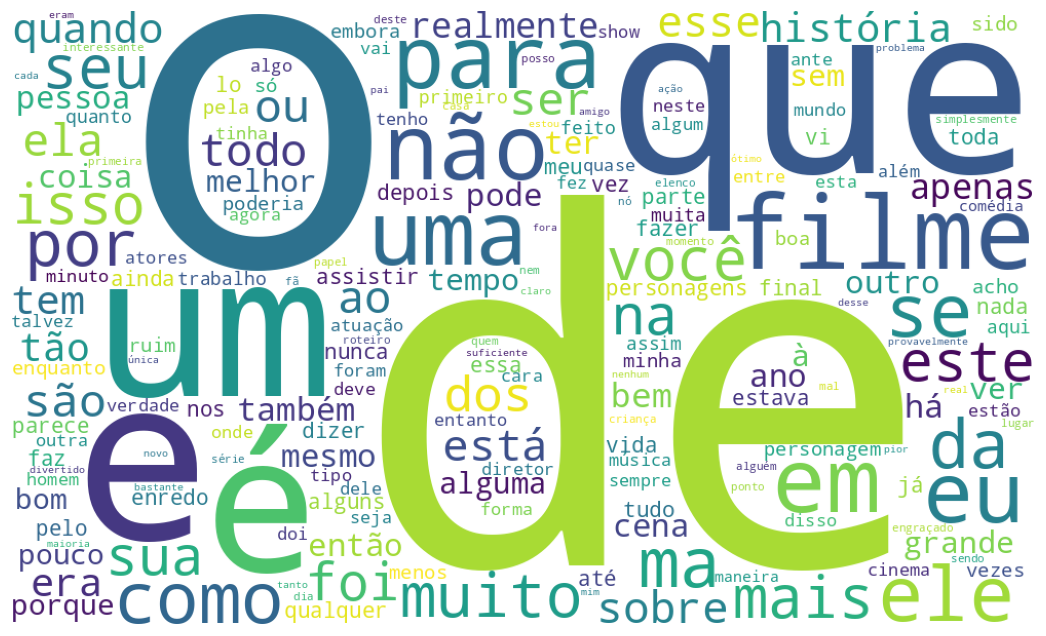

In [16]:
plt.figure(figsize=(20, 8))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

**Limpeza:** caracteres especiais

In [17]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [18]:
amostra = spark.createDataFrame([
    ("Oi, JP! Blz?",),
    ("$$$\\ |~ Parabéns ~ |\\$$$",),
    ("(#amovc #paz&amor ^.^)",),
    ("\"bora *-* \"",),
    ("=>->'....`~` vc foi selecionad@ ´´´...'<-<-",),
    ("{comprar: arroz; feijão e pepino} //",),
    (":|\"#$%&'()*+,-./:;<=>?@[\\]^_`{|}~",),
    ("ana@gmail.com",)
], ['textos'])

In [19]:
import pyspark.sql.functions as f

amostra = amostra.withColumn('text_regex', f.regexp_replace('textos', '\\p{Punct}', ''))

amostra.show(truncate=False)

+-------------------------------------------+------------------------------+
|textos                                     |text_regex                    |
+-------------------------------------------+------------------------------+
|Oi, JP! Blz?                               |Oi JP Blz                     |
|$$$\ |~ Parabéns ~ |\$$$                   |  Parabéns                    |
|(#amovc #paz&amor ^.^)                     |amovc pazamor                 |
|"bora *-* "                                |bora                          |
|=>->'....`~` vc foi selecionad@ ´´´...'<-<-| vc foi selecionad ´´´        |
|{comprar: arroz; feijão e pepino} //       |comprar arroz feijão e pepino |
|:|"#$%&'()*+,-./:;<=>?@[\]^_`{|}~          |                              |
|ana@gmail.com                              |anagmailcom                   |
+-------------------------------------------+------------------------------+



In [20]:
# retirando espaço em brancos do exemplo

amostra = amostra.withColumn('texto_limpo', f.trim(amostra.text_regex))

amostra.show(truncate=False)

+-------------------------------------------+------------------------------+-----------------------------+
|textos                                     |text_regex                    |texto_limpo                  |
+-------------------------------------------+------------------------------+-----------------------------+
|Oi, JP! Blz?                               |Oi JP Blz                     |Oi JP Blz                    |
|$$$\ |~ Parabéns ~ |\$$$                   |  Parabéns                    |Parabéns                     |
|(#amovc #paz&amor ^.^)                     |amovc pazamor                 |amovc pazamor                |
|"bora *-* "                                |bora                          |bora                         |
|=>->'....`~` vc foi selecionad@ ´´´...'<-<-| vc foi selecionad ´´´        |vc foi selecionad ´´´        |
|{comprar: arroz; feijão e pepino} //       |comprar arroz feijão e pepino |comprar arroz feijão e pepino|
|:|"#$%&'()*+,-./:;<=>?@[\]^_`{|}~   

In [21]:
#  1.Tirando caracteres especiais dos dados

df = df.withColumn('text_regex', f.regexp_replace('text_en', '\\p{Punct}', ''))
df.limit(2).show(truncate=False)

+---+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [22]:
# 2.Tirando espaços do começo e final de cada frase
# poderia ser usado o regex porém vamos usar o Trim
df = df.withColumn('texto_limpo', f.trim(df.text_regex))
df.limit(2).show(truncate=False)

+---+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

**Tokenização:** divisão em tokens

In [23]:
# 3.Tokenização de dados
# palavras de uma frase
# [palavras] [de][uma][frase]

from pyspark.ml.feature import Tokenizer

tokenizer = Tokenizer(inputCol='texto_limpo', outputCol='tokens')
tokenizado = tokenizer.transform(df)

In [24]:
tokenizado.select('texto_limpo', 'tokens').show()

+--------------------+--------------------+
|         texto_limpo|              tokens|
+--------------------+--------------------+
|Once again Mr Cos...|[once, again, mr,...|
|This is an exampl...|[this, is, an, ex...|
|First of all I ha...|[first, of, all, ...|
|Not even the Beat...|[not, even, the, ...|
|Brass pictures mo...|[brass, pictures,...|
|A funny thing hap...|[a, funny, thing,...|
|This German horro...|[this, german, ho...|
|Being a longtime ...|[being, a, longti...|
|Tokyo Eyes tells ...|[tokyo, eyes, tel...|
|Wealthy horse ran...|[wealthy, horse, ...|
|Cage plays a drun...|[cage, plays, a, ...|
|First of all I wo...|[first, of, all, ...|
|So tell me  what ...|[so, tell, me, , ...|
|A big disappointm...|[a, big, disappoi...|
|This film is abso...|[this, film, is, ...|
|Heres a decidedly...|[heres, a, decide...|
|At the bottom end...|[at, the, bottom,...|
|Earth has been de...|[earth, has, been...|
|Many people are s...|[many, people, ar...|
|New York family i...|[new, york

In [25]:
# Total de tokens em que os comentários foram divididos.
from pyspark.sql.types import IntegerType
countTokens = f.udf(lambda tokens: len(tokens), IntegerType())
tokenizado = tokenizado.withColumn('tokens_count', countTokens(f.col('tokens')))
tokenizado.select('texto_limpo', 'tokens')\
                  .withColumn('Freq_tokens', countTokens(f.col('tokens'))).show()


+--------------------+--------------------+-----------+
|         texto_limpo|              tokens|Freq_tokens|
+--------------------+--------------------+-----------+
|Once again Mr Cos...|[once, again, mr,...|        168|
|This is an exampl...|[this, is, an, ex...|        232|
|First of all I ha...|[first, of, all, ...|        215|
|Not even the Beat...|[not, even, the, ...|        308|
|Brass pictures mo...|[brass, pictures,...|        238|
|A funny thing hap...|[a, funny, thing,...|        115|
|This German horro...|[this, german, ho...|        156|
|Being a longtime ...|[being, a, longti...|        136|
|Tokyo Eyes tells ...|[tokyo, eyes, tel...|        129|
|Wealthy horse ran...|[wealthy, horse, ...|        160|
|Cage plays a drun...|[cage, plays, a, ...|        109|
|First of all I wo...|[first, of, all, ...|        333|
|So tell me  what ...|[so, tell, me, , ...|        243|
|A big disappointm...|[a, big, disappoi...|        110|
|This film is abso...|[this, film, is, ...|     

**StopWords**: remoção de ruídos
podemos utilizar o `StopWordsRemover()` nativo do spark ou `stopwords()`biblioteca nltk do Python. Ambas as linguagens dã suporte para o português. Primeiro vamos aplicar em um exemplo e depois em nossa base de dados.

In [26]:
# Exemplo pequeno

data = [
    (1, 'Spark é legal e NLP com saprk é facil'),
    (0, 'Spark MLlib não ajuda muito'),
    (1, 'O MLlib do spak ajuda muito e é facil')
]

colNames = ['label', 'texto_limpo']
dados = spark.createDataFrame(data, colNames)

In [27]:
# Importando bibliotecas (python)

import nltk

nltk.download('stopwords')

from nltk.corpus import stopwords

stop_a = stopwords.words('portuguese')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [28]:
# Importando bibliotecas (pyspark)
from pyspark.ml.feature import StopWordsRemover

stop_b = StopWordsRemover.loadDefaultStopWords('portuguese')

In [29]:
# comparando os diferentes stopwords stop_a

from pyspark.ml.feature import Tokenizer

tokenizer = Tokenizer(inputCol='texto_limpo', outputCol='tokens')
tokenized = tokenizer.transform(dados)

In [30]:
remover = StopWordsRemover(inputCol='tokens', outputCol='texto_final', stopWords=stop_a)

dados = remover.transform(tokenized)

In [31]:
dados.show(truncate=False)

+-----+-------------------------------------+-----------------------------------------------+---------------------------------+
|label|texto_limpo                          |tokens                                         |texto_final                      |
+-----+-------------------------------------+-----------------------------------------------+---------------------------------+
|1    |Spark é legal e NLP com saprk é facil|[spark, é, legal, e, nlp, com, saprk, é, facil]|[spark, legal, nlp, saprk, facil]|
|0    |Spark MLlib não ajuda muito          |[spark, mllib, não, ajuda, muito]              |[spark, mllib, ajuda]            |
|1    |O MLlib do spak ajuda muito e é facil|[o, mllib, do, spak, ajuda, muito, e, é, facil]|[mllib, spak, ajuda, facil]      |
+-----+-------------------------------------+-----------------------------------------------+---------------------------------+



In [32]:
# stop_b
remover = StopWordsRemover(inputCol='tokens', outputCol='texto_final', stopWords=stop_b)

dados = remover.transform(tokenized)

In [33]:
dados.show(truncate=False)

+-----+-------------------------------------+-----------------------------------------------+---------------------------------------+
|label|texto_limpo                          |tokens                                         |texto_final                            |
+-----+-------------------------------------+-----------------------------------------------+---------------------------------------+
|1    |Spark é legal e NLP com saprk é facil|[spark, é, legal, e, nlp, com, saprk, é, facil]|[spark, é, legal, nlp, saprk, é, facil]|
|0    |Spark MLlib não ajuda muito          |[spark, mllib, não, ajuda, muito]              |[spark, mllib, ajuda]                  |
|1    |O MLlib do spak ajuda muito e é facil|[o, mllib, do, spak, ajuda, muito, e, é, facil]|[mllib, spak, ajuda, é, facil]         |
+-----+-------------------------------------+-----------------------------------------------+---------------------------------------+



In [34]:
remover = StopWordsRemover(inputCol='tokens', outputCol='texto_final')

feature_data = remover.transform(tokenizado)

In [35]:
feature_data.limit(10).show()

+---+--------------------+--------------------+---------+--------------------+--------------------+--------------------+------------+--------------------+
| id|             text_en|             text_pt|sentiment|          text_regex|         texto_limpo|              tokens|tokens_count|         texto_final|
+---+--------------------+--------------------+---------+--------------------+--------------------+--------------------+------------+--------------------+
|  1|Once again Mr. Co...|Mais uma vez, o S...|      neg|Once again Mr Cos...|Once again Mr Cos...|[once, again, mr,...|         168|[mr, costner, dra...|
|  2|This is an exampl...|Este é um exemplo...|      neg|This is an exampl...|This is an exampl...|[this, is, an, ex...|         232|[example, majorit...|
|  3|First of all I ha...|Primeiro de tudo ...|      neg|First of all I ha...|First of all I ha...|[first, of, all, ...|         215|[first, hate, mor...|
|  4|Not even the Beat...|Nem mesmo os Beat...|      neg|Not even the 

In [36]:
# Contagem de tokens antes e depois do StopWords
feature_data.select('tokens', 'texto_final')\
                  .withColumn('Freq_tokens', countTokens(f.col('tokens')))\
                  .withColumn('Freq_tokens_limpos', countTokens(f.col('texto_final'))).show()

+--------------------+--------------------+-----------+------------------+
|              tokens|         texto_final|Freq_tokens|Freq_tokens_limpos|
+--------------------+--------------------+-----------+------------------+
|[once, again, mr,...|[mr, costner, dra...|        168|                73|
|[this, is, an, ex...|[example, majorit...|        232|               131|
|[first, of, all, ...|[first, hate, mor...|        215|               111|
|[not, even, the, ...|[even, beatles, w...|        308|               169|
|[brass, pictures,...|[brass, pictures,...|        238|               140|
|[a, funny, thing,...|[funny, thing, ha...|        115|                52|
|[this, german, ho...|[german, horror, ...|        156|                74|
|[being, a, longti...|[longtime, fan, j...|        136|                73|
|[tokyo, eyes, tel...|[tokyo, eyes, tel...|        129|                75|
|[wealthy, horse, ...|[wealthy, horse, ...|        160|                99|
|[cage, plays, a, ...|[ca

**Vetorização das palavras:** Bag of words.

contabilizando as palavras do nosso Dataset

In [37]:
# utilizando o dataset de exemplo
from pyspark.ml.feature import CountVectorizer

cv = CountVectorizer(inputCol='texto_final', outputCol='CountVec')
model = cv.fit(dados)
dados = model.transform(dados)

In [38]:
# qntd de palavras diferentes, index de cada palavra no model.vocabulary, frequencia das palavras
# (9,[0,2,4,5,7,8],[2.0,1.0,1.0,1.0,1.0,1.0])
dados.select('texto_final', 'CountVec').show(truncate=False)

+---------------------------------------+-------------------------------------------+
|texto_final                            |CountVec                                   |
+---------------------------------------+-------------------------------------------+
|[spark, é, legal, nlp, saprk, é, facil]|(9,[0,2,4,5,7,8],[2.0,1.0,1.0,1.0,1.0,1.0])|
|[spark, mllib, ajuda]                  |(9,[1,2,3],[1.0,1.0,1.0])                  |
|[mllib, spak, ajuda, é, facil]         |(9,[0,1,3,4,6],[1.0,1.0,1.0,1.0,1.0])      |
+---------------------------------------+-------------------------------------------+



In [39]:
# ordem das palavras
model.vocabulary

['é', 'mllib', 'spark', 'ajuda', 'facil', 'nlp', 'spak', 'legal', 'saprk']

In [40]:
# Countvectorizer para nosso dataset original
from pyspark.ml.feature import CountVectorizer

cv = CountVectorizer(inputCol='texto_final', outputCol='CountVec')
model = cv.fit(feature_data)
count_Vectorizer_features = model.transform(feature_data)

CountVectorizers = count_Vectorizer_features.select('texto_final', 'CountVec').limit(5).show()

+--------------------+--------------------+
|         texto_final|            CountVec|
+--------------------+--------------------+
|[mr, costner, dra...|(216507,[0,7,8,11...|
|[example, majorit...|(216507,[1,2,3,8,...|
|[first, hate, mor...|(216507,[0,2,4,11...|
|[even, beatles, w...|(216507,[0,1,2,4,...|
|[brass, pictures,...|(216507,[1,3,5,8,...|
+--------------------+--------------------+



In [41]:
model.vocabulary

['movie',
 'film',
 'one',
 '',
 'like',
 'good',
 'even',
 'time',
 'really',
 'see',
 'story',
 'much',
 'well',
 'get',
 'great',
 'bad',
 'people',
 'also',
 'first',
 'dont',
 'movies',
 'made',
 'make',
 'films',
 'way',
 'characters',
 'think',
 'watch',
 'seen',
 'many',
 'two',
 'never',
 'character',
 'acting',
 'love',
 'plot',
 'little',
 'best',
 'know',
 'show',
 'ever',
 'life',
 'better',
 'say',
 'still',
 'end',
 'scene',
 'scenes',
 'man',
 'something',
 'go',
 'im',
 'watching',
 'back',
 'real',
 'thing',
 'actors',
 'didnt',
 'doesnt',
 'years',
 'funny',
 'actually',
 'though',
 'makes',
 'find',
 'nothing',
 'another',
 'look',
 'lot',
 'going',
 'work',
 'new',
 'every',
 'old',
 'part',
 'cant',
 'us',
 'want',
 'pretty',
 'director',
 'quite',
 'thats',
 'cast',
 'things',
 'got',
 'seems',
 'young',
 'around',
 'take',
 'fact',
 'thought',
 'enough',
 'big',
 'world',
 'give',
 'horror',
 'ive',
 'may',
 'saw',
 'however',
 'isnt',
 'always',
 'long',
 'with

**Hashing TF:** Uma alternativa para o CountVector.

é gerada a mesma estrutura, porém aqui limitamos o número de palavras contabilizadas.

In [42]:
# Hashing TF limita a quantidade de palavras.

from pyspark.ml.feature import HashingTF

hashingTF = HashingTF(inputCol='texto_final', outputCol='HashingTF')
hashingTF.setNumFeatures(50)

HTFfeaturizedData = hashingTF.transform(count_Vectorizer_features)

In [43]:
# Como definimos 50 palavras, ele mostrada somente isso. E o restante das palavras serão ignoradas tanto no nosso vocabulary quanto na contagem de frequencia das palavras
HTFfeaturizedData.select('texto_final', 'HashingTF').limit(5).show()

+--------------------+--------------------+
|         texto_final|           HashingTF|
+--------------------+--------------------+
|[mr, costner, dra...|(50,[0,5,6,7,8,10...|
|[example, majorit...|(50,[0,1,2,3,4,5,...|
|[first, hate, mor...|(50,[0,1,2,3,5,6,...|
|[even, beatles, w...|(50,[0,1,2,3,4,5,...|
|[brass, pictures,...|(50,[0,1,2,3,4,5,...|
+--------------------+--------------------+



**TF-IDF:** Contabiliza e pondera as palavras.

A fórmula TF-IDF (Term Frequency-Inverse Document Frequency) é utilizada para calcular o peso de uma palavra em um documento, considerando sua frequência no texto e sua raridade em um conjunto de documentos (corpus)


A fórmula geral é:

***TF-IDF(t, d, D) = TF(t,d) x IDF(t,D)***

Onde:

t = Termo/Palavra

d = Documento específico

D = Conjunto de documentos (Corpus)

In [44]:
# Com TF-IDF: entendemos não só frequência mas tbm como a palavra se comporta em todo conjunto de dados.
# Baseado em uma fórmula.

from pyspark.ml.feature import IDF
idf = IDF(inputCol = 'HashingTF', outputCol = 'features')
idfModel = idf.fit(HTFfeaturizedData)

TFIDFeaturizedData = idfModel.transform(HTFfeaturizedData)

In [45]:
TFIDFeaturizedData.select('texto_final', 'features').limit(5).show(truncate=False)

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

**Pepiline de transformação**

Codificando: váriavel resposta.

Vamos ensinar que todas essas palavras estarão associadas ao sentimento de depoimento, positivo ou negativo, entretando precisamos codificar `neg` e `pos` para 0 e 1. E para isso vamos usar `StringIndexer`.

In [46]:
# Covertendo com pyspark nossos dados que estão em texto para números com StringIndexer

TFIDFeaturizedData.groupBy('sentiment').count().show()


+---------+-----+
|sentiment|count|
+---------+-----+
|      pos|24694|
|      neg|24765|
+---------+-----+



In [50]:
# codificando váriavel resposta
# 1. replace
# 2.stringindexer (sentiment -> label)

from pyspark.ml.feature import StringIndexer

stringindexer = StringIndexer(inputCol='sentiment', outputCol='label')
df = stringindexer.fit(df).transform(df)

In [51]:
1 # Quem é 0 e quem é 1
df.groupBy(['sentiment', 'label']).count().show()

+---------+-----+-----+
|sentiment|label|count|
+---------+-----+-----+
|      pos|  1.0|24694|
|      neg|  0.0|24765|
+---------+-----+-----+



**Pipeline:** transformação de dados

In [52]:
from pyspark.ml import Pipeline

tokenizer = Tokenizer(inputCol='texto_limpo', outputCol='tokens')
stopwords = StopWordsRemover(inputCol='tokens', outputCol='texto_final')
hashingTF = HashingTF(inputCol=stopwords.getOutputCol(), outputCol='HTF', numFeatures=1000)
tfidf = IDF(inputCol = 'HTF', outputCol = 'features')

pipeline = Pipeline(stages=[tokenizer, stopwords, hashingTF, tfidf])

In [54]:
dados.transformados = pipeline.fit(df).transform(df)

In [55]:
dados.transformados.limit(5).show()

+---+--------------------+--------------------+---------+--------------------+--------------------+-----+--------------------+--------------------+--------------------+--------------------+
| id|             text_en|             text_pt|sentiment|          text_regex|         texto_limpo|label|              tokens|         texto_final|                 HTF|            features|
+---+--------------------+--------------------+---------+--------------------+--------------------+-----+--------------------+--------------------+--------------------+--------------------+
|  1|Once again Mr. Co...|Mais uma vez, o S...|      neg|Once again Mr Cos...|Once again Mr Cos...|  0.0|[once, again, mr,...|[mr, costner, dra...|(1000,[10,21,34,4...|(1000,[10,21,34,4...|
|  2|This is an exampl...|Este é um exemplo...|      neg|This is an exampl...|This is an exampl...|  0.0|[this, is, an, ex...|[example, majorit...|(1000,[0,3,11,12,...|(1000,[0,3,11,12,...|
|  3|First of all I ha...|Primeiro de tudo ...|   

**Treinando o modelo:** possíveis modelos

regressão logística

árvore de decisão

XGBoost

In [58]:
# Vamos utilizar a ávore de decisão como modelo de classificação
# cria uma série de regras para classificar

featureDF = dados.transformados.select('features', 'label')

In [59]:
featureDF.limit(5).show(truncate=False)

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [60]:
# tipo lido pelo modelo
featureDF.printSchema()

root
 |-- features: vector (nullable = true)
 |-- label: double (nullable = false)



In [61]:
#Pipeline de transformação e ajuste
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml import Pipeline

tokenizer = Tokenizer(inputCol='texto_limpo', outputCol='tokens')
stopwords = StopWordsRemover(inputCol='tokens', outputCol='texto_final')
hashingTF = HashingTF(inputCol=stopwords.getOutputCol(), outputCol='HTF', numFeatures=1000)
tfidf = IDF(inputCol = 'HTF', outputCol = 'features')
dt = DecisionTreeClassifier(labelCol='label', featuresCol='features', maxDepth=10)

pipeline = Pipeline(stages=[tokenizer, stopwords, hashingTF, tfidf, dt])

**Amostra e Treino**

In [63]:
# separação dos dados

train, test = df.randomSplit([0.7, 0.3], seed=101)

In [64]:
# ajustando o modelo com a pipeline
dt_model = pipeline.fit(train)

In [66]:
# aplicando na base teste
predictions = dt_model.transform(test)

In [67]:
predictions.show()

+---+--------------------+--------------------+---------+--------------------+--------------------+-----+--------------------+--------------------+--------------------+--------------------+---------------+--------------------+----------+
| id|             text_en|             text_pt|sentiment|          text_regex|         texto_limpo|label|              tokens|         texto_final|                 HTF|            features|  rawPrediction|         probability|prediction|
+---+--------------------+--------------------+---------+--------------------+--------------------+-----+--------------------+--------------------+--------------------+--------------------+---------------+--------------------+----------+
|  5|Brass pictures mo...|Filmes de fotos d...|      neg|Brass pictures mo...|Brass pictures mo...|  0.0|[brass, pictures,...|[brass, pictures,...|(1000,[3,6,7,11,3...|(1000,[3,6,7,11,3...|   [90.0,446.0]|[0.16791044776119...|       1.0|
|  6|A funny thing hap...|Uma coisa engraça...| 

**Teste e métricas**

In [68]:


predictions.select(['label', 'prediction']).show()

+-----+----------+
|label|prediction|
+-----+----------+
|  0.0|       1.0|
|  0.0|       1.0|
|  0.0|       1.0|
|  0.0|       0.0|
|  0.0|       0.0|
|  0.0|       0.0|
|  0.0|       0.0|
|  0.0|       0.0|
|  0.0|       1.0|
|  0.0|       0.0|
|  0.0|       0.0|
|  0.0|       0.0|
|  0.0|       0.0|
|  0.0|       1.0|
|  0.0|       0.0|
|  0.0|       0.0|
|  0.0|       0.0|
|  0.0|       0.0|
|  0.0|       1.0|
|  0.0|       0.0|
+-----+----------+
only showing top 20 rows


In [69]:
# métrica acuracia

from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='accuracy')
accuracy = evaluator.evaluate(predictions)

In [71]:
print("Acurácia = %s" % (accuracy))

Acurácia = 0.6709942149872191


**Nova frase:** explicando os resultados

In [72]:
# este é sem dúvida o pior filme que já assisti, odiei a atuação dos atores.
# adorei o filme, excelente atuação!

In [75]:
nova_base = spark.createDataFrame ([
    (0, 'This is without doubt the worst movie i have ever seen, I hated the acting of the actors.'),
    (1, 'I loved the movie, excellent acting!'),
], ['id', 'texto_limpo'])

In [76]:
nova_class = dt_model.transform(nova_base)

In [77]:
nova_class.show()

+---+--------------------+--------------------+--------------------+--------------------+--------------------+-------------+--------------------+----------+
| id|         texto_limpo|              tokens|         texto_final|                 HTF|            features|rawPrediction|         probability|prediction|
+---+--------------------+--------------------+--------------------+--------------------+--------------------+-------------+--------------------+----------+
|  0|This is without d...|[this, is, withou...|[without, doubt, ...|(1000,[35,43,269,...|(1000,[35,43,269,...| [304.0,69.0]|[0.81501340482573...|       0.0|
|  1|I loved the movie...|[i, loved, the, m...|[loved, movie,, e...|(1000,[185,543,73...|(1000,[185,543,73...|[190.0,912.0]|[0.17241379310344...|       1.0|
+---+--------------------+--------------------+--------------------+--------------------+--------------------+-------------+--------------------+----------+

